# Machine Failure Prediction using Machine Learning  
## Predictive Maintenance for Industry 4.0

This project aims to predict machine failure in advance using sensor data.
Predictive maintenance helps manufacturing companies reduce downtime,
maintenance costs, and production losses.



## Problem Statement

Manufacturing industries face unexpected machine breakdowns that cause:
- Production downtime
- Increased maintenance cost
- Loss of revenue

Traditional maintenance methods are reactive or time-based.
Hence, there is a need for a data-driven predictive maintenance system.


## Project Objective

- Build a Machine Learning model to predict machine failure
- Use sensor and operational data
- Help industries perform maintenance before breakdown occurs


In [19]:
# Import Required Libraries
# ==============================

# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set visualization style
sns.set(style="whitegrid")



In [20]:
# Load dataset
data = pd.read_csv("ai4i2020.csv")
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



## Data Understanding

We analyze:
- Number of records and features
- Data types
- Missing values



In [21]:
# Dataset shape
data.shape
# Dataset information
data.info()
# Statistical summary
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## Data Cleaning

- Removed irrelevant identifier columns
- Dataset has no missing values
- Prepared data for ML modeling


In [22]:
# Drop unnecessary identifier columns safely
data.drop(columns=["UDI", "Product ID", "Product_ID"], errors="ignore", inplace=True)

# Verify columns
print(data.columns)


Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')


## Encoding Categorical Features

The machine type is categorical.
We apply Label Encoding to convert it into numerical format.


In [23]:
# Initialize Label Encoder
le = LabelEncoder()

# Encode machine type
data["Type"] = le.fit_transform(data["Type"])

# Check encoded values
data["Type"].value_counts()


Type
1    6000
2    2997
0    1003
Name: count, dtype: int64

## Target Variable Distribution

Analyzing how many machines failed vs not failed.


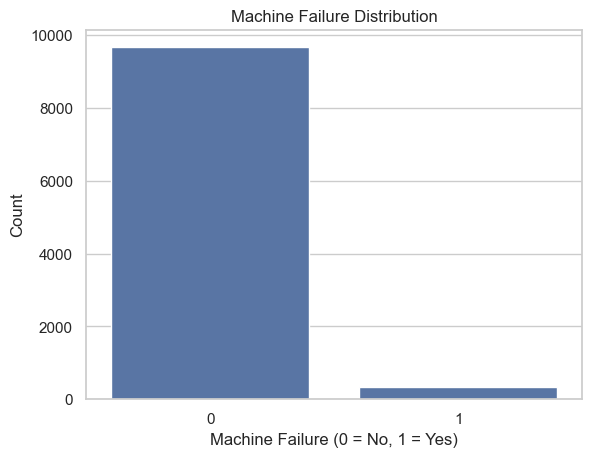

In [24]:
plt.figure()
sns.countplot(x="Machine failure", data=data)
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


## Feature Selection and Dataset Splitting

- Separated input features (X) and target variable (y)
- Removed non-predictive and leakage-prone columns
- Split dataset into training and testing sets
  - Training data: 80%
  - Testing data: 20%



In [25]:
# Define input features and target
X = data.drop("Machine failure", axis=1)
y = data["Machine failure"]

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((8000, 11), (2000, 11))

## Model Selection

We selected Random Forest Classifier because:
- It handles non-linearity well
- Robust to noise
- Performs well on tabular sensor data


In [26]:

# Initialize Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,     # number of trees
    random_state=42
)

# Train model on training data
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

## Model Prediction

Predict machine failure on test data.


In [27]:
# Make predictions
y_pred = rf_model.predict(X_test)

# Sample predictions
y_pred[:10]


array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

## Model Evaluation

We evaluate the model using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix


In [28]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Random Forest Accuracy: 0.999

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



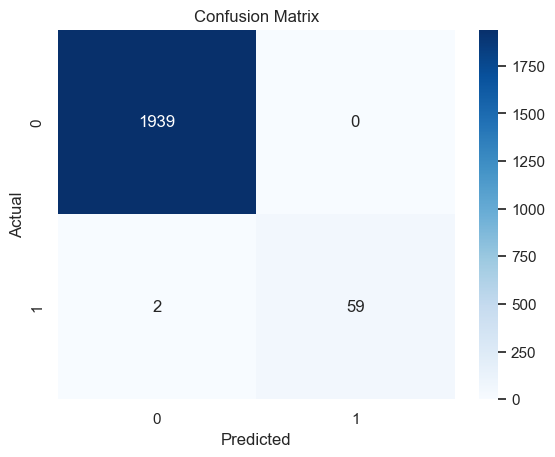

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Feature Importance

Identifies which sensor features contribute most to machine failure prediction.


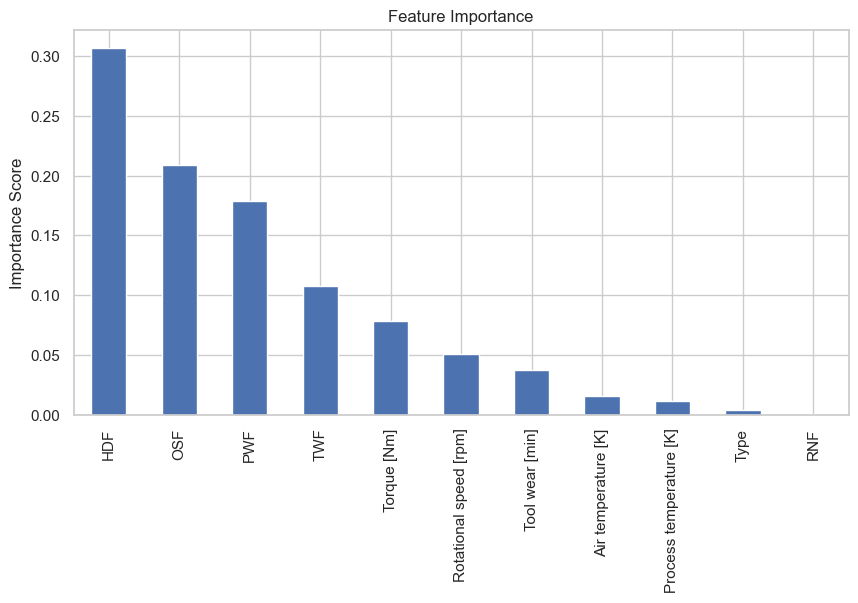

In [30]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(10,5))
feature_importance.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()


## Sample Prediction

Predict machine failure for a single machine record.


In [31]:
# Select one machine sample
sample = X_test.iloc[0:1]

# Predict failure
prediction = rf_model.predict(sample)

if prediction[0] == 1:
    print("⚠ Machine is likely to FAIL. Schedule maintenance.")
else:
    print("✅ Machine is operating normally.")


✅ Machine is operating normally.


## Conclusion

- Successfully built a predictive maintenance ML model
- Achieved high accuracy using sensor data
- The model helps reduce downtime and maintenance cost
- Suitable for Industry 4.0 manufacturing environments


In [32]:
import pickle

# Save trained model
with open("model.pkl", "wb") as file:
    pickle.dump(rf_model, file)
